# Notebook 06 - Embeddings V1 (Sentence-Transformers)

**Objectif**: Calculer des embeddings d'énoncés avec Sentence-Transformers et réaliser une analyse exploratoire centrée sur les embeddings.

**Modèle**: `sentence-transformers/all-MiniLM-L6-v2` (384 dimensions)

**Pipeline**:
1. Chargement du dataset préprocessé
2. Identification des labels binaires (8 tags prioritaires, déjà dans le dataset)
3. Preprocessing texte: LaTeX → tokens, normalisation, **conservation des nombres**
4. Troncature simple (budget max de mots)
5. Calcul des embeddings
6. Analyse des centroids par label
7. Distributions de similarité cosine (positifs vs négatifs)

**Livrables**:
- `embeddings`: matrice (n_docs, 384) normalisée L2
- `centroids`: dict {tag: vecteur centroid}
- `centroid_sim_matrix`: matrice 8x8 de similarité cosine entre centroids
- Figures: heatmap centroids, distributions par label


In [1]:
!uv pip install sentence_transformers

Using Python 3.13.11 environment at: /app/.venv
Resolved 46 packages in 1.14s                                        
Uninstalled 1 package in 88ms
░░░░░░░░░░░░░░░░░░░░ [0/1] Installing wheels...                                 warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 7.15s7.5                             
 - nvidia-nccl-cu12==2.29.2
 + nvidia-nccl-cu12==2.27.5


# 1. Tests fonctionnalités

---
## 1. Imports & Configuration


In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

# Configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Seed pour reproductibilité
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Tags prioritaires
PRIORITY_TAGS = [
    'math',
    'graphs',
    'strings',
    'number theory',
    'trees',
    'geometry',
    'games',
    'probabilities'
]

# Chemins
DATA_DIR = Path('../data/processed')
OUTPUTS_DIR = Path('../docs/embeddings')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration OK")
print(f"Tags prioritaires: {len(PRIORITY_TAGS)}")
print(f"Output directory: {OUTPUTS_DIR}")


/app/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration OK
Tags prioritaires: 8
Output directory: ../docs/embeddings


---
## 2. Chargement du Dataset Préprocessé

On charge le dataset issu du notebook `04_preprocessing_pipeline.ipynb`.

**Colonnes attendues**:
- `unified_document`: texte concaténé avec LaTeX
- `tags`: liste de tags originaux


In [3]:
# Chargement du dataset train (on travaille sur le train pour l'EDA)
train_path = DATA_DIR / 'train_preprocessed.parquet'

if not train_path.exists():
    raise FileNotFoundError(f"Dataset non trouvé: {train_path}")

df = pd.read_parquet(train_path)

print(f"Dataset chargé: {len(df)} documents")
print(f"Colonnes: {df.columns.tolist()}")

# Vérifications
assert 'unified_document' in df.columns, "Colonne 'unified_document' manquante"
assert 'tags' in df.columns, "Colonne 'tags' manquante"

# Aperçu
print("\nAperçu du dataset:")
df[['unified_document', 'tags']].head(3)


Dataset chargé: 3978 documents
Colonnes: ['prob_desc_time_limit', 'prob_desc_sample_outputs', 'src_uid', 'prob_desc_notes', 'prob_desc_description', 'prob_desc_output_spec', 'prob_desc_input_spec', 'prob_desc_output_to', 'prob_desc_input_from', 'lang', 'lang_cluster', 'difficulty', 'file_name', 'code_uid', 'prob_desc_memory_limit', 'prob_desc_sample_inputs', 'exec_outcome', 'source_code', 'prob_desc_created_at', 'tags', 'hidden_unit_tests', 'prob_desc_description_translated', 'prob_desc_input_spec_translated', 'prob_desc_output_spec_translated', 'prob_desc_notes_translated', 'prob_desc_description_translated_hash', 'tags_priority', 'target_games', 'target_geometry', 'target_graphs', 'target_math', 'target_number theory', 'target_probabilities', 'target_strings', 'target_trees', 'time_limit_seconds', 'clean_description', 'latex_features_desc', 'nb_latex_blocks', 'nb_latex_symbols', 'latex_density', 'latex_symbols_density', 'has_le', 'has_ldots', 'has_dots', 'has_leq', 'has_cdot', 'has_n

,unified_document,tags
0,"[DESC] Numbers $$$1, 2, 3, \dots n$$$ (each in...","[greedy, constructive algorithms, math, implem..."
1,[DESC] Polycarp is working on a new project ca...,[implementation]
2,[DESC] You are given a tree with $$$n$$$ verti...,"[graphs, constructive algorithms, graph matchi..."


---
## 3. Identification des Labels Binaires (8 Tags Prioritaires)

Le dataset préprocessé contient déjà les colonnes `target_{tag}` pour les 8 tags prioritaires.
On identifie simplement ces colonnes pour les analyses ultérieures.


In [4]:
# Identifier les colonnes target existantes
label_columns = []
for tag in PRIORITY_TAGS:
    col_name = f'target_{tag}'
    if col_name in df.columns:
        label_columns.append(col_name)
    else:
        print(f"⚠️  Colonne {col_name} non trouvée!")

# Vérification
assert len(label_columns) == len(PRIORITY_TAGS), f"Nombre de colonnes incorrect: {len(label_columns)}/{len(PRIORITY_TAGS)}"

print("Labels binaires identifiés:")
print("="*80)
for tag, col in zip(PRIORITY_TAGS, label_columns):
    n_pos = df[col].sum()
    pct_pos = (n_pos / len(df)) * 100
    print(f"  {col:25s}: {n_pos:4d} positifs ({pct_pos:5.2f}%)")

print("="*80)
print(f"Total documents: {len(df)}")


Labels binaires identifiés:
  target_math              : 1124 positifs (28.26%)
  target_graphs            :  433 positifs (10.88%)
  target_strings           :  338 positifs ( 8.50%)
  target_number theory     :  280 positifs ( 7.04%)
  target_trees             :  258 positifs ( 6.49%)
  target_geometry          :  132 positifs ( 3.32%)
  target_games             :   84 positifs ( 2.11%)
  target_probabilities     :   74 positifs ( 1.86%)
Total documents: 3978


---
## 4. Preprocessing du Texte

**Objectif**: Nettoyer le texte pour les embeddings en:
1. Remplaçant les blocs LaTeX par `MATHBLOCK`
2. Remplaçant les commandes LaTeX spécifiques par des tokens (ex: `\gcd` → `LATEX_GCD`)
3. Normalisant les espaces
4. Appliquant un lowercase

**IMPORTANT**: Contrairement au TF-IDF, on **ne tokenise PAS les nombres** ici. Les embeddings peuvent tirer parti des valeurs numériques dans leur contexte.


In [5]:
# Commandes LaTeX à remplacer par des tokens
LATEX_COMMANDS_TO_TOKEN = {
    r'\\gcd': 'LATEX_GCD',
    r'\\lcm': 'LATEX_LCM',
    r'\\binom': 'LATEX_BINOM',
    r'\\Pr': 'LATEX_PR',
    r'\\sqrt': 'LATEX_SQRT',
    r'\\sum': 'LATEX_SUM',
    r'\\prod': 'LATEX_PROD',
    r'\\log': 'LATEX_LOG',
    r'\\sin': 'LATEX_SIN',
    r'\\cos': 'LATEX_COS',
    r'\\tan': 'LATEX_TAN',
    r'\\min': 'LATEX_MIN',
    r'\\max': 'LATEX_MAX',
}

def clean_text_for_embeddings(text: str, replace_latex: bool = True) -> str:
    """
    Nettoie le texte pour les embeddings.
    
    Différences avec clean_text pour TF-IDF:
    - PAS de tokenisation des nombres
    - Traitement LaTeX paramétrable
    
    Parameters
    ----------
    text : str
        Texte brut avec LaTeX
    replace_latex : bool, default=True
        Si True, remplace le LaTeX par des tokens (MATHBLOCK, LATEX_GCD, etc.)
        Si False, garde le LaTeX brut (utile pour SPECTER)
        
    Returns
    -------
    str
        Texte nettoyé
    """
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    if replace_latex:
        # 1. Remplacer les blocs LaTeX par MATHBLOCK
        text = re.sub(r'\$\$\$.*?\$\$\$', ' MATHBLOCK ', text, flags=re.DOTALL)
        text = re.sub(r'\$\$.*?\$\$', ' MATHBLOCK ', text, flags=re.DOTALL)
        text = re.sub(r'\$.*?\$', ' MATHBLOCK ', text, flags=re.DOTALL)
        text = re.sub(r'\\\[.*?\\\]', ' MATHBLOCK ', text, flags=re.DOTALL)
        text = re.sub(r'\\\(.*?\\\)', ' MATHBLOCK ', text, flags=re.DOTALL)
        
        # 2. Remplacer commandes LaTeX spécifiques
        for latex_cmd, token in LATEX_COMMANDS_TO_TOKEN.items():
            text = re.sub(latex_cmd, f' {token} ', text, flags=re.IGNORECASE)
    
    # 3. Normaliser les espaces (toujours fait)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    
    # 4. Lowercase (toujours fait)
    text = text.lower()
    
    return text

# Test de la fonction
test_text = "Calculate $\\gcd(a, b)$ where $a = 123$ and $b = 456$. The sum is $\\sum_{i=1}^{n} i$."
print("Exemple de nettoyage:")
print(f"Avant: {test_text}")
print(f"Après: {clean_text_for_embeddings(test_text)}")

# Application au dataset
print("\nApplication du preprocessing au dataset...")
df['unified_document_clean'] = df['unified_document'].apply(clean_text_for_embeddings)

# Statistiques
print("\nStatistiques après preprocessing:")
df['text_length_words'] = df['unified_document_clean'].apply(lambda x: len(x.split()))
print(f"Longueur en mots:")
print(f"  Min:    {df['text_length_words'].min()}")
print(f"  Q25:    {df['text_length_words'].quantile(0.25):.0f}")
print(f"  Median: {df['text_length_words'].median():.0f}")
print(f"  Q75:    {df['text_length_words'].quantile(0.75):.0f}")
print(f"  P95:    {df['text_length_words'].quantile(0.95):.0f}")
print(f"  Max:    {df['text_length_words'].max()}")

# Exemples
print("\nExemples de textes nettoyés:")
for i in range(3):
    print(f"\nExemple {i+1} (longueur: {df.iloc[i]['text_length_words']} mots):")
    print(df.iloc[i]['unified_document_clean'][:300] + "...")


Exemple de nettoyage:
Avant: Calculate $\gcd(a, b)$ where $a = 123$ and $b = 456$. The sum is $\sum_{i=1}^{n} i$.
Après: calculate mathblock where mathblock and mathblock . the sum is mathblock .

Application du preprocessing au dataset...

Statistiques après preprocessing:
Longueur en mots:
  Min:    74
  Q25:    257
  Median: 331
  Q75:    419
  P95:    580
  Max:    1156

Exemples de textes nettoyés:

Exemple 1 (longueur: 254 mots):
[desc] numbers mathblock (each integer from mathblock to mathblock once) are written on a board. in one operation you can erase any two numbers mathblock and mathblock from the board and write one integer mathblock rounded up instead.you should perform the given operation mathblock times and make th...

Exemple 2 (longueur: 306 mots):
[desc] polycarp is working on a new project called "polychat". following modern tendencies in it, he decided, that this project should contain chat as well. to achieve this goal, polycarp has spent several hours in front of

---
## 5. Troncature Simple

Les modèles Sentence-Transformers ont une limite de tokens (typiquement 256-512 pour MiniLM).

On applique une troncature simple:
- Garder les premiers `max_words` mots
- Valeur par défaut: 400 mots (~ 512 tokens avec marge)


In [6]:
def truncate_text(text: str, max_words: int = 400) -> str:
    """
    Tronque le texte aux premiers max_words mots.
    
    Parameters
    ----------
    text : str
        Texte à tronquer
    max_words : int, default=400
        Nombre maximum de mots à conserver
        
    Returns
    -------
    str
        Texte tronqué
    """
    if pd.isna(text):
        return ""
    
    words = str(text).split()
    if len(words) <= max_words:
        return text
    
    return ' '.join(words[:max_words])

# Application
MAX_WORDS = 400
print(f"Application de la troncature (max_words={MAX_WORDS})...")

df['unified_document_trunc'] = df['unified_document_clean'].apply(
    lambda x: truncate_text(x, max_words=MAX_WORDS)
)
# Statistiques post-troncature
df['text_length_words_after'] = df['unified_document_trunc'].apply(lambda x: len(x.split()))

n_truncated = (df['text_length_words'] > MAX_WORDS).sum()
pct_truncated = (n_truncated / len(df)) * 100

print(f"\nStatistiques post-troncature:")
print(f"  Documents tronqués: {n_truncated} / {len(df)} ({pct_truncated:.2f}%)")
print(f"\nLongueur en mots (après troncature):")
print(f"  Min:    {df['text_length_words_after'].min()}")
print(f"  Median: {df['text_length_words_after'].median():.0f}")
print(f"  P95:    {df['text_length_words_after'].quantile(0.95):.0f}")
print(f"  Max:    {df['text_length_words_after'].max()}")

# Exemple de document tronqué
if n_truncated > 0:
    idx_trunc = df[df['text_length_words'] > MAX_WORDS].index[0]
    print(f"\nExemple de document tronqué (index {idx_trunc}):")
    print(f"  Longueur avant: {df.loc[idx_trunc, 'text_length_words']} mots")
    print(f"  Longueur après: {df.loc[idx_trunc, 'text_length_words_after']} mots")
    print(f"  Texte: {df.loc[idx_trunc, 'unified_document_trunc'][:200]}...")


Application de la troncature (max_words=400)...

Statistiques post-troncature:
  Documents tronqués: 1157 / 3978 (29.08%)

Longueur en mots (après troncature):
  Min:    74
  Median: 331
  P95:    400
  Max:    400

Exemple de document tronqué (index 4):
  Longueur avant: 420 mots
  Longueur après: 400 mots
  Texte: [desc] in summer informatics school, if a student doesn't behave well, teachers make a hole in his badge. and today one of the teachers caught a group of mathblock students doing yet another trick. le...


## 6. Calcul des Embeddings avec MiniLM

**Modèle**: `sentence-transformers/all-MiniLM-L6-v2`
- Dimensions: 384
- Max sequence length: 256 tokens (notre troncature à 400 mots devrait passer)
- Performances: bon compromis vitesse/qualité

**Paramètres d'encoding**:
- `batch_size=64`: traitement par batch pour efficacité
- `show_progress_bar=True`: affichage de la progression
- `convert_to_numpy=True`: sortie en numpy array
- `normalize_embeddings=True`: normalisation L2 (cosine similarity = dot product)


In [7]:
# Chargement du modèle
print("Chargement du modèle Sentence-Transformers...")
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print(f"Modèle chargé: {model.get_sentence_embedding_dimension()} dimensions")

# Préparation des textes
texts = df['unified_document_trunc'].fillna("").tolist()
print(f"\nEncoding de {len(texts)} documents...")

# Encoding
embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # Normalisation L2
)

# Vérifications
print(f"\nEmbeddings calculés:")
print(f"  Shape: {embeddings.shape}")
print(f"  Dtype: {embeddings.dtype}")
print(f"  Norme L2 (premier doc): {np.linalg.norm(embeddings[0]):.6f}")
print(f"  Memory: {embeddings.nbytes / 1024**2:.2f} MB")

# Vérifier la normalisation
norms = np.linalg.norm(embeddings, axis=1)
print(f"\nVérification normalisation L2:")
print(f"  Min norm: {norms.min():.6f}")
print(f"  Max norm: {norms.max():.6f}")
print(f"  Mean norm: {norms.mean():.6f}")

Chargement du modèle Sentence-Transformers...
Modèle chargé: 384 dimensions

Encoding de 3978 documents...


Batches: 100%|██████████| 63/63 [04:35<00:00,  4.37s/it]


Embeddings calculés:
  Shape: (3978, 384)
  Dtype: float32
  Norme L2 (premier doc): 1.000000
  Memory: 5.83 MB

Vérification normalisation L2:
  Min norm: 1.000000
  Max norm: 1.000000
  Mean norm: 1.000000


### Sauvegarde des Embeddings (optionnel)


In [8]:
# Sauvegarde (optionnel)
embeddings_path = DATA_DIR / 'embeddings_minilm_train.npy'
np.save(embeddings_path, embeddings)
print(f"Embeddings sauvegardés: {embeddings_path}")

Embeddings sauvegardés: ../data/processed/embeddings_minilm_train.npy


---
## 7. Analyse des Centroids

### 7.1 Calcul des Centroids par Label

Pour chaque tag prioritaire:
1. Sélectionner tous les documents positifs
2. Calculer la moyenne des embeddings → centroid
3. Re-normaliser le centroid (L2)

Le centroid représente le "prototype" d'un document de ce tag dans l'espace d'embeddings.


In [9]:
# Calcul des centroids
centroids = {}

print("Calcul des centroids par label:")
print("="*80)

for tag, col in zip(PRIORITY_TAGS, label_columns):
    # Indices des documents positifs
    pos_idx = df[col] == 1
    n_pos = pos_idx.sum()
    
    if n_pos == 0:
        print(f"⚠️  {tag:20s}: Aucun document positif!")
        centroids[tag] = np.zeros(embeddings.shape[1])
        continue
    
    # Moyenne des embeddings positifs
    centroid = embeddings[pos_idx].mean(axis=0)
    
    # Re-normalisation L2
    centroid_norm = np.linalg.norm(centroid)
    if centroid_norm > 0:
        centroid = centroid / centroid_norm
    
    centroids[tag] = centroid
    
    print(f"✓ {tag:20s}: {n_pos:4d} docs positifs, norm={np.linalg.norm(centroid):.6f}")

print("="*80)
print(f"Centroids calculés pour {len(centroids)} labels")


Calcul des centroids par label:
✓ math                : 1124 docs positifs, norm=1.000000
✓ graphs              :  433 docs positifs, norm=1.000000
✓ strings             :  338 docs positifs, norm=1.000000
✓ number theory       :  280 docs positifs, norm=1.000000
✓ trees               :  258 docs positifs, norm=1.000000
✓ geometry            :  132 docs positifs, norm=1.000000
✓ games               :   84 docs positifs, norm=1.000000
✓ probabilities       :   74 docs positifs, norm=1.000000
Centroids calculés pour 8 labels


### 7.2 Matrice de Similarité Cosine entre Centroids

Cette matrice montre à quel point les différents tags sont "proches" dans l'espace d'embeddings.

**Interprétation**:
- Valeur élevée (proche de 1): les documents des deux tags se ressemblent
- Valeur faible: les documents sont distincts
- Diagonale = 1 (chaque centroid avec lui-même)


In [10]:
# Calcul de la matrice de similarité
centroid_matrix = np.array([centroids[tag] for tag in PRIORITY_TAGS])
centroid_sim_matrix = cosine_similarity(centroid_matrix)

print("Matrice de similarité cosine entre centroids:")
print("="*80)

# Affichage sous forme de tableau
centroid_sim_df = pd.DataFrame(
    centroid_sim_matrix,
    index=PRIORITY_TAGS,
    columns=PRIORITY_TAGS
)
print(centroid_sim_df.round(3))

# Statistiques
print("\nStatistiques (hors diagonale):")
off_diag = centroid_sim_matrix[~np.eye(len(PRIORITY_TAGS), dtype=bool)]
print(f"  Min:    {off_diag.min():.4f}")
print(f"  Mean:   {off_diag.mean():.4f}")
print(f"  Median: {np.median(off_diag):.4f}")
print(f"  Max:    {off_diag.max():.4f}")

# Paires les plus similaires
print("\nTop 5 paires de tags les plus similaires:")
pairs = []
for i in range(len(PRIORITY_TAGS)):
    for j in range(i+1, len(PRIORITY_TAGS)):
        pairs.append((PRIORITY_TAGS[i], PRIORITY_TAGS[j], centroid_sim_matrix[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
for i, (tag1, tag2, sim) in enumerate(pairs_sorted[:5], 1):
    print(f"  {i}. {tag1:20s} <-> {tag2:20s}: {sim:.4f}")


Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.885    0.789          0.971  0.788     0.813  0.795   
graphs         0.885   1.000    0.699          0.826  0.936     0.848  0.795   
strings        0.789   0.699    1.000          0.754  0.630     0.598  0.640   
number theory  0.971   0.826    0.754          1.000  0.744     0.752  0.712   
trees          0.788   0.936    0.630          0.744  1.000     0.743  0.696   
geometry       0.813   0.848    0.598          0.752  0.743     1.000  0.698   
games          0.795   0.795    0.640          0.712  0.696     0.698  1.000   
probabilities  0.873   0.839    0.709          0.807  0.762     0.740  0.845   

               probabilities  
math                   0.873  
graphs                 0.839  
strings                0.709  
number theory          0.807  
trees                  0.762  
geometry               0.740  
games           

### 7.3 Heatmap de Similarité entre Centroids


In [11]:
def slugify_tag(tag: str) -> str:
    """Convertit un tag en slug (espaces -> underscores)."""
    return tag.replace(' ', '_').replace('-', '_').lower()


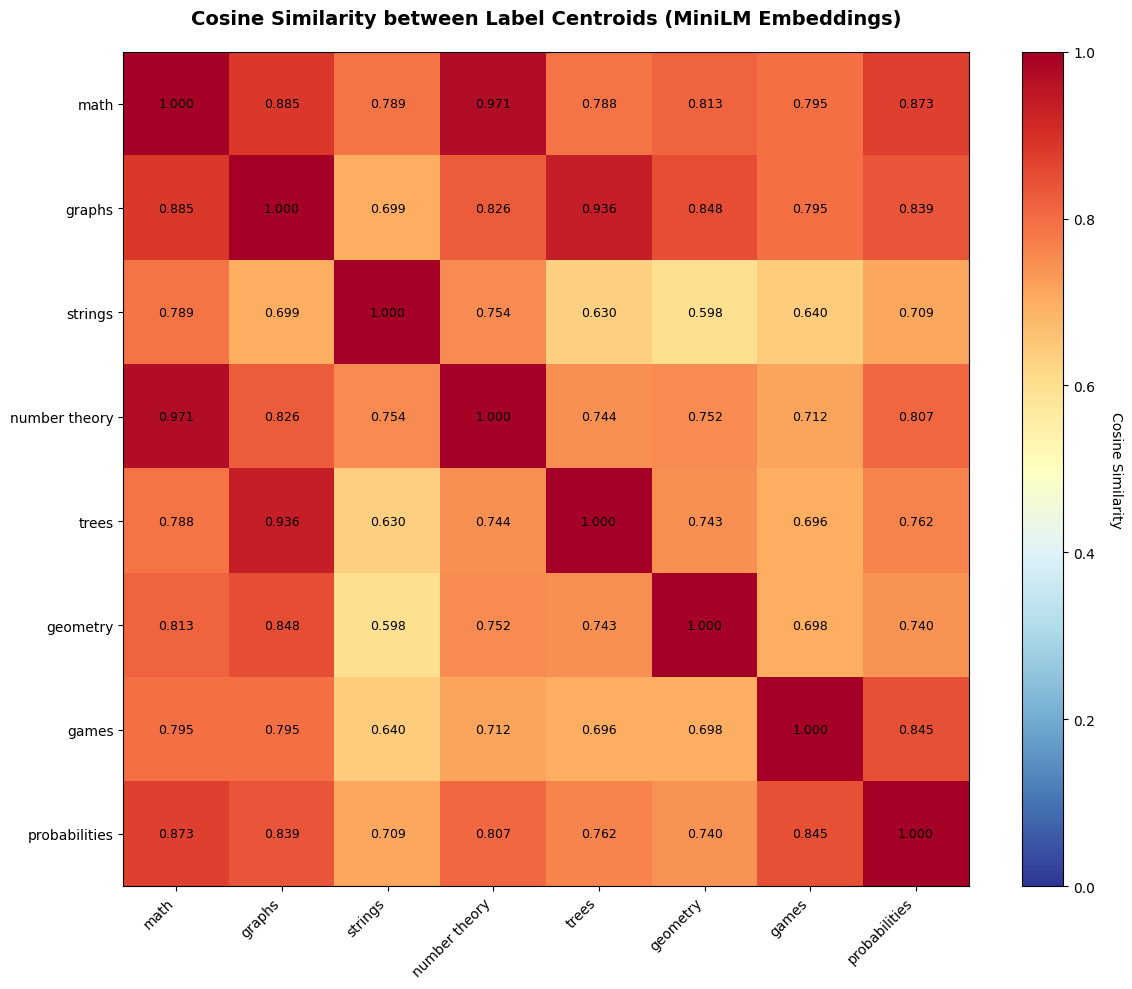

Heatmap sauvegardée: ../docs/embeddings/centroid_similarity_heatmap.png


In [12]:
# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(centroid_sim_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')

# Ticks
ax.set_xticks(np.arange(len(PRIORITY_TAGS)))
ax.set_yticks(np.arange(len(PRIORITY_TAGS)))
ax.set_xticklabels(PRIORITY_TAGS, rotation=45, ha='right')
ax.set_yticklabels(PRIORITY_TAGS)

# Annotations
for i in range(len(PRIORITY_TAGS)):
    for j in range(len(PRIORITY_TAGS)):
        text = ax.text(j, i, f"{centroid_sim_matrix[i, j]:.3f}",
                      ha="center", va="center", color="black", fontsize=9)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Similarity', rotation=270, labelpad=20)

ax.set_title('Cosine Similarity between Label Centroids (MiniLM Embeddings)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'centroid_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Heatmap sauvegardée: {OUTPUTS_DIR / 'centroid_similarity_heatmap.png'}")


---
## 7.4 Distributions de Similarité Cosine (Positifs vs Négatifs)

Pour chaque tag, on analyse:
1. La distribution des similarités cosine entre chaque document et le centroid du tag
2. Comparaison entre documents positifs (label=1) et négatifs (label=0)

**Interprétation**:
- Si les positifs ont des similarités significativement plus élevées → bonne séparation
- Si les distributions se chevauchent beaucoup → difficulté à distinguer


In [13]:
def plot_similarity_distribution(tag: str, col: str, centroid: np.ndarray, 
                                 embeddings: np.ndarray, df: pd.DataFrame,
                                 output_dir: Path) -> Dict:
    """
    Plot la distribution de similarité cosine pour un tag.
    
    Parameters
    ----------
    tag : str
        Nom du tag
    col : str
        Nom de la colonne label
    centroid : np.ndarray
        Vecteur centroid du tag
    embeddings : np.ndarray
        Matrice d'embeddings
    df : pd.DataFrame
        DataFrame avec les labels
    output_dir : Path
        Répertoire de sortie
        
    Returns
    -------
    dict
        Statistiques de séparation
    """
    # Calcul des similarités (dot product car normalisés)
    similarities = embeddings @ centroid
    
    # Séparation positifs/négatifs
    pos_mask = df[col] == 1
    neg_mask = df[col] == 0
    
    sim_pos = similarities[pos_mask]
    sim_neg = similarities[neg_mask]
    
    # Statistiques
    stats = {
        'tag': tag,
        'n_pos': len(sim_pos),
        'n_neg': len(sim_neg),
        'mean_pos': sim_pos.mean(),
        'mean_neg': sim_neg.mean(),
        'median_pos': np.median(sim_pos),
        'median_neg': np.median(sim_neg),
        'std_pos': sim_pos.std(),
        'std_neg': sim_neg.std(),
        'delta_mean': sim_pos.mean() - sim_neg.mean(),
    }
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bins = np.linspace(similarities.min(), similarities.max(), 50)
    
    ax.hist(sim_neg, bins=bins, alpha=0.6, label=f'Négatifs (n={len(sim_neg)})', 
            color='steelblue', density=True)
    ax.hist(sim_pos, bins=bins, alpha=0.6, label=f'Positifs (n={len(sim_pos)})', 
            color='coral', density=True)
    
    # Lignes de moyennes
    ax.axvline(stats['mean_neg'], color='steelblue', linestyle='--', linewidth=2, 
               label=f"Moyenne neg: {stats['mean_neg']:.3f}")
    ax.axvline(stats['mean_pos'], color='coral', linestyle='--', linewidth=2,
               label=f"Moyenne pos: {stats['mean_pos']:.3f}")
    
    ax.set_xlabel('Cosine Similarity avec Centroid', fontsize=12)
    ax.set_ylabel('Densité', fontsize=12)
    ax.set_title(f"Distribution Similarité: {tag}\n"
                f"Δmean = {stats['delta_mean']:.3f}", 
                fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Sauvegarde
    slug = slugify_tag(tag)
    output_path = output_dir / f'dist_similarity_{slug}.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    return stats

# Application pour tous les tags
print("Génération des distributions de similarité...")
print("="*80)

all_stats = []

for tag, col in zip(PRIORITY_TAGS, label_columns):
    centroid = centroids[tag]
    stats = plot_similarity_distribution(
        tag=tag,
        col=col,
        centroid=centroid,
        embeddings=embeddings,
        df=df,
        output_dir=OUTPUTS_DIR
    )
    all_stats.append(stats)
    
    print(f"✓ {tag:20s}: Δmean={stats['delta_mean']:.4f}, "
          f"mean_pos={stats['mean_pos']:.3f}, mean_neg={stats['mean_neg']:.3f}")

print("="*80)

# Résumé sous forme de DataFrame
stats_df = pd.DataFrame(all_stats)
print("\nRésumé des statistiques:")
print(stats_df[['tag', 'n_pos', 'delta_mean', 'mean_pos', 'mean_neg']].to_string(index=False))

# Tags avec meilleure/pire séparation
stats_df_sorted = stats_df.sort_values('delta_mean', ascending=False)
print("\nTags avec meilleure séparation (Δmean élevé):")
print(stats_df_sorted[['tag', 'delta_mean']].head(3).to_string(index=False))

print("\nTags avec pire séparation (Δmean faible):")
print(stats_df_sorted[['tag', 'delta_mean']].tail(3).to_string(index=False))


Génération des distributions de similarité...
✓ math                : Δmean=0.0627, mean_pos=0.574, mean_neg=0.512
✓ graphs              : Δmean=0.0537, mean_pos=0.550, mean_neg=0.496
✓ strings             : Δmean=0.1892, mean_pos=0.616, mean_neg=0.427
✓ number theory       : Δmean=0.1286, mean_pos=0.623, mean_neg=0.494
✓ trees               : Δmean=0.1711, mean_pos=0.611, mean_neg=0.440
✓ geometry            : Δmean=0.1093, mean_pos=0.560, mean_neg=0.451
✓ games               : Δmean=0.2472, mean_pos=0.688, mean_neg=0.441
✓ probabilities       : Δmean=0.0560, mean_pos=0.536, mean_neg=0.480

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
         math   1124    0.062696  0.574385  0.511689
       graphs    433    0.053706  0.549625  0.495919
      strings    338    0.189195  0.616353  0.427159
number theory    280    0.128593  0.622973  0.494380
        trees    258    0.171100  0.611497  0.440397
     geometry    132    0.109311  0.560329  0.451018
     

In [14]:
def show_top_documents(tag: str, col: str, centroid: np.ndarray, 
                       embeddings: np.ndarray, df: pd.DataFrame, n: int = 5):
    """
    Affiche les top documents pour un tag.
    """
    # Calcul des similarités
    similarities = embeddings @ centroid
    
    # Masques
    pos_mask = df[col] == 1
    neg_mask = df[col] == 0
    
    print(f"\n{'='*80}")
    print(f"TAG: {tag.upper()}")
    print(f"{'='*80}")
    
    # Top positifs
    print(f"\n🎯 Top {n} Positifs (plus similaires au centroid):")
    print("-"*80)
    
    pos_indices = df[pos_mask].index
    pos_sims = similarities[pos_mask]
    top_pos_idx = pos_indices[np.argsort(pos_sims)[-n:][::-1]]
    
    for rank, idx in enumerate(top_pos_idx, 1):
        sim = similarities[idx]
        text = df.loc[idx, 'unified_document_trunc'][:150]
        tags = df.loc[idx, 'tags']
        print(f"\n{rank}. Similarité: {sim:.4f}")
        print(f"   Tags: {tags}")
        print(f"   Texte: {text}...")
    
    # Hard negatives
    print(f"\n⚠️  Top {n} Hard Negatives (négatifs similaires au centroid):")
    print("-"*80)
    
    neg_indices = df[neg_mask].index
    neg_sims = similarities[neg_mask]
    
    if len(neg_sims) > 0:
        top_neg_idx = neg_indices[np.argsort(neg_sims)[-n:][::-1]]
        
        for rank, idx in enumerate(top_neg_idx, 1):
            sim = similarities[idx]
            text = df.loc[idx, 'unified_document_trunc'][:150]
            tags = df.loc[idx, 'tags']
            print(f"\n{rank}. Similarité: {sim:.4f}")
            print(f"   Tags: {tags}")
            print(f"   Texte: {text}...")
    else:
        print("Aucun document négatif.")

# Sélection de 2-3 tags à analyser
tags_to_analyze = ['probabilities', 'number theory', 'games']

for tag in tags_to_analyze:
    if tag not in PRIORITY_TAGS:
        continue
    
    idx = PRIORITY_TAGS.index(tag)
    col = label_columns[idx]
    centroid = centroids[tag]
    
    show_top_documents(tag, col, centroid, embeddings, df, n=5)



TAG: PROBABILITIES

🎯 Top 5 Positifs (plus similaires au centroid):
--------------------------------------------------------------------------------

1. Similarité: 0.7073
   Tags: ['bitmasks' 'combinatorics' 'dp' 'graphs' 'math' 'probabilities']
   Texte: [desc] william is not only interested in trading but also in betting on sports matches. mathblock teams participate in each match. each team is charac...

2. Similarité: 0.6697
   Tags: ['dp' 'probabilities' 'math']
   Texte: [desc] let mathblock be an array of integers mathblock . let's define mathblock as a minimal size of a partition of mathblock into subsegments such th...

3. Similarité: 0.6674
   Tags: ['dp' 'combinatorics' 'probabilities']
   Texte: [desc] an online contest will soon be held on forcecoders, a large competitive programming platform. the authors have prepared mathblock problems; and...

4. Similarité: 0.6627
   Tags: ['probabilities' 'math']
   Texte: [desc] slime and his mathblock friends are at a party. slime

---
## 9. Résumé Final

**Livrables créés**:
1. ✅ `embeddings`: matrice (n_docs, 384) normalisée L2
2. ✅ `centroids`: dict {tag: vecteur centroid} pour 8 tags prioritaires
3. ✅ `centroid_sim_matrix`: matrice 8x8 de similarité cosine entre centroids
4. ✅ Figures sauvegardées dans `docs/embeddings/`:
   - Heatmap de similarité entre centroids
   - 8 distributions de similarité (positifs vs négatifs)

**Variables disponibles pour la suite**:
- `df`: DataFrame avec colonnes `unified_document_clean`, `unified_document_trunc`, 8 labels binaires
- `embeddings`: numpy array (n_docs, 384)
- `centroids`: dict
- `centroid_sim_matrix`: numpy array (8, 8)
- `label_columns`: liste des noms de colonnes labels

**Prochaines étapes possibles**:
1. Modélisation avec embeddings (notebook 07)
2. Réduction dimensionnelle (UMAP/t-SNE) pour visualisation
3. Clustering et analyse d'outliers
4. Approche hybride: combinaison TF-IDF + Embeddings


In [15]:
print("\n" + "="*80)
print("RÉSUMÉ FINAL")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   Nombre de documents: {len(df)}")
print(f"   Colonnes créées: {len(label_columns)} labels binaires")

print(f"\n🔢 Embeddings:")
print(f"   Shape: {embeddings.shape}")
print(f"   Dtype: {embeddings.dtype}")
print(f"   Normalisés L2: Oui")
print(f"   Sauvegardés: {DATA_DIR / 'embeddings_minilm_train.npy'}")

print(f"\n🎯 Centroids:")
print(f"   Nombre de centroids: {len(centroids)}")
print(f"   Tags: {list(centroids.keys())}")

print(f"\n📈 Similarités entre centroids:")
print(f"   Min (hors diag): {off_diag.min():.4f}")
print(f"   Mean (hors diag): {off_diag.mean():.4f}")
print(f"   Max (hors diag): {off_diag.max():.4f}")

print(f"\n📊 Séparation positifs/négatifs:")
print(f"   Meilleur Δmean: {stats_df_sorted.iloc[0]['tag']} ({stats_df_sorted.iloc[0]['delta_mean']:.4f})")
print(f"   Pire Δmean: {stats_df_sorted.iloc[-1]['tag']} ({stats_df_sorted.iloc[-1]['delta_mean']:.4f})")

print(f"\n💾 Figures sauvegardées:")
figures = list(OUTPUTS_DIR.glob('*.png'))
print(f"   Répertoire: {OUTPUTS_DIR}")
print(f"   Nombre de figures: {len(figures)}")
for fig in figures:
    print(f"   - {fig.name}")

print("\n" + "="*80)
print("✅ Notebook 06 - Embeddings V1: TERMINÉ")
print("="*80)



RÉSUMÉ FINAL

📊 Dataset:
   Nombre de documents: 3978
   Colonnes créées: 8 labels binaires

🔢 Embeddings:
   Shape: (3978, 384)
   Dtype: float32
   Normalisés L2: Oui
   Sauvegardés: ../data/processed/embeddings_minilm_train.npy

🎯 Centroids:
   Nombre de centroids: 8
   Tags: ['math', 'graphs', 'strings', 'number theory', 'trees', 'geometry', 'games', 'probabilities']

📈 Similarités entre centroids:
   Min (hors diag): 0.5983
   Mean (hors diag): 0.7745
   Max (hors diag): 0.9713

📊 Séparation positifs/négatifs:
   Meilleur Δmean: games (0.2472)
   Pire Δmean: graphs (0.0537)

💾 Figures sauvegardées:
   Répertoire: ../docs/embeddings
   Nombre de figures: 73
   - all-MiniLM-L6-v2_desc_only_centroid_similarity.png
   - all-MiniLM-L6-v2_desc_only_dist_games.png
   - all-MiniLM-L6-v2_desc_only_dist_geometry.png
   - all-MiniLM-L6-v2_desc_only_dist_graphs.png
   - all-MiniLM-L6-v2_desc_only_dist_math.png
   - all-MiniLM-L6-v2_desc_only_dist_number_theory.png
   - all-MiniLM-L6-v2_desc_

---
# 2. Fonction d'Évaluation Rapide d'Embedders

Cette section fournit une fonction réutilisable pour tester rapidement différents modèles d'embeddings sur le même dataset.


In [16]:
def evaluate_embedder(
    model_name: str,
    df: pd.DataFrame,
    text_column: str,
    target_columns: List[str],
    priority_tags: List[str],
    output_prefix: str,
    max_words: int = 400,
    batch_size: int = 64,
    output_dir: Path = OUTPUTS_DIR,
    data_dir: Path = DATA_DIR,
    verbose: bool = True,
    replace_latex: bool = True
) -> Dict:
    """
    Évalue rapidement un modèle d'embeddings sur le dataset.
    
    Cette fonction permet de tester différents embedders et de comparer
    leurs performances en termes de séparation des classes.
    
    Parameters
    ----------
    model_name : str
        Nom du modèle Sentence-Transformers (ex: 'all-mpnet-base-v2')
    df : pd.DataFrame
        DataFrame contenant les données
    text_column : str
        Nom de la colonne contenant le texte à embedder
    target_columns : list of str
        Liste des colonnes target (ex: ['target_math', 'target_graphs', ...])
    priority_tags : list of str
        Liste des tags prioritaires (ex: ['math', 'graphs', ...])
    output_prefix : str
        Préfixe pour les fichiers de sortie (ex: 'mpnet', 'minilm')
    max_words : int, default=400
        Nombre maximum de mots à conserver
    batch_size : int, default=64
        Taille des batchs pour l'encoding
    output_dir : Path, default=OUTPUTS_DIR
        Répertoire pour sauvegarder les figures
    data_dir : Path, default=DATA_DIR
        Répertoire pour sauvegarder les embeddings
    verbose : bool, default=True
        Afficher les informations de progression
    replace_latex : bool, default=True
        Si True, remplace le LaTeX par des tokens (MATHBLOCK, LATEX_GCD, etc.)
        Si False, garde le LaTeX brut (utile pour SPECTER)
        
    Returns
    -------
    dict
        Dictionnaire contenant:
        - 'embeddings': numpy array (n_docs, n_dims)
        - 'centroids': dict {tag: centroid}
        - 'centroid_sim_matrix': matrice de similarité (n_tags, n_tags)
        - 'stats': DataFrame avec statistiques par tag (delta_mean, etc.)
        - 'model_name': nom du modèle
        - 'embedding_dim': dimension des embeddings
    
    Examples
    --------
    >>> results = evaluate_embedder(
    ...     model_name='all-mpnet-base-v2',
    ...     df=df,
    ...     text_column='unified_document_clean',
    ...     target_columns=label_columns,
    ...     priority_tags=PRIORITY_TAGS,
    ...     output_prefix='mpnet'
    ... )
    >>> print(f"Meilleur tag: {results['stats'].iloc[0]['tag']} (Δmean={results['stats'].iloc[0]['delta_mean']:.3f})")
    """
    
    if verbose:
        print("\n" + "="*80)
        print(f"ÉVALUATION EMBEDDER: {model_name}")
        print("="*80)
    
    # 1. Vérifications
    assert text_column in df.columns, f"Colonne '{text_column}' non trouvée"
    assert len(target_columns) == len(priority_tags), "Nombre de target_columns != priority_tags"
    
    # 2. Preprocessing du texte (si pas déjà fait)
    if verbose:
        print(f"\n[1/7] Preprocessing du texte...")
    
    # On nettoie le texte
    texts_clean = df[text_column].apply(lambda x: clean_text_for_embeddings(x, replace_latex=replace_latex))
    
    # Troncature
    texts_trunc = texts_clean.apply(lambda x: truncate_text(x, max_words=max_words))
    texts = texts_trunc.fillna("").tolist()
    
    n_truncated = (texts_clean.apply(lambda x: len(x.split())) > max_words).sum()
    if verbose:
        print(f"   Documents tronqués: {n_truncated} / {len(df)} ({n_truncated/len(df)*100:.1f}%)")
    
    # 3. Chargement du modèle
    if verbose:
        print(f"\n[2/7] Chargement du modèle '{model_name}'...")
    
    try:
        model = SentenceTransformer(model_name)
        embedding_dim = model.get_sentence_embedding_dimension()
        if verbose:
            print(f"   Modèle chargé: {embedding_dim} dimensions")
    except Exception as e:
        print(f"❌ Erreur lors du chargement du modèle: {e}")
        raise
    
    # 4. Calcul des embeddings
    if verbose:
        print(f"\n[3/7] Encoding de {len(texts)} documents...")
    
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=verbose,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    
    if verbose:
        print(f"   Shape: {embeddings.shape}")
        print(f"   Memory: {embeddings.nbytes / 1024**2:.2f} MB")
    
    # 5. Calcul des centroids
    if verbose:
        print(f"\n[4/7] Calcul des centroids...")
    
    centroids = {}
    for tag, col in zip(priority_tags, target_columns):
        pos_idx = df[col] == 1
        n_pos = pos_idx.sum()
        
        if n_pos == 0:
            centroids[tag] = np.zeros(embedding_dim)
            continue
        
        centroid = embeddings[pos_idx].mean(axis=0)
        centroid_norm = np.linalg.norm(centroid)
        if centroid_norm > 0:
            centroid = centroid / centroid_norm
        
        centroids[tag] = centroid
    
    # 6. Matrice de similarité entre centroids
    if verbose:
        print(f"\n[5/7] Calcul de la matrice de similarité...")
    
    centroid_matrix = np.array([centroids[tag] for tag in priority_tags])
    centroid_sim_matrix = cosine_similarity(centroid_matrix)
    
        # Affichage
    centroid_sim_df = pd.DataFrame(
        centroid_sim_matrix,
        index=priority_tags,
        columns=priority_tags
    )
    
    # Calcul des statistiques hors diagonale (toujours nécessaire pour le résultat final)
    off_diag = centroid_sim_matrix[~np.eye(len(priority_tags), dtype=bool)]
    
    if verbose:
        print("\nMatrice de similarité cosine entre centroids:")
        print(centroid_sim_df.round(3))
        
        print(f"\nStatistiques (hors diagonale):")
        print(f"  Min:    {off_diag.min():.4f}")
        print(f"  Mean:   {off_diag.mean():.4f}")
        print(f"  Median: {np.median(off_diag):.4f}")
        print(f"  Max:    {off_diag.max():.4f}")
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(centroid_sim_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
    
    ax.set_xticks(np.arange(len(priority_tags)))
    ax.set_yticks(np.arange(len(priority_tags)))
    ax.set_xticklabels(priority_tags, rotation=45, ha='right')
    ax.set_yticklabels(priority_tags)
    
    for i in range(len(priority_tags)):
        for j in range(len(priority_tags)):
            ax.text(j, i, f"{centroid_sim_matrix[i, j]:.3f}",
                   ha="center", va="center", color="black", fontsize=9)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Cosine Similarity', rotation=270, labelpad=20)
    
    ax.set_title(f'Centroid Similarity: {model_name}', 
                 fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    heatmap_path = output_dir / f'{output_prefix}_centroid_similarity.png'
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    if verbose:
        print(f"\nHeatmap sauvegardée: {heatmap_path}")
    
    # 7. Distributions de similarité (positifs vs négatifs)
    if verbose:
        print(f"\n[6/7] Calcul des distributions de similarité...")
    
    all_stats = []
    
    for tag, col in zip(priority_tags, target_columns):
        centroid = centroids[tag]
        similarities = embeddings @ centroid
        
        pos_mask = df[col] == 1
        neg_mask = df[col] == 0
        
        sim_pos = similarities[pos_mask]
        sim_neg = similarities[neg_mask]
        
        stats = {
            'tag': tag,
            'n_pos': len(sim_pos),
            'n_neg': len(sim_neg),
            'mean_pos': sim_pos.mean(),
            'mean_neg': sim_neg.mean(),
            'median_pos': np.median(sim_pos),
            'median_neg': np.median(sim_neg),
            'std_pos': sim_pos.std(),
            'std_neg': sim_neg.std(),
            'delta_mean': sim_pos.mean() - sim_neg.mean(),
        }
        all_stats.append(stats)
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 6))
        bins = np.linspace(similarities.min(), similarities.max(), 50)
        
        ax.hist(sim_neg, bins=bins, alpha=0.6, label=f'Négatifs (n={len(sim_neg)})', 
                color='steelblue', density=True)
        ax.hist(sim_pos, bins=bins, alpha=0.6, label=f'Positifs (n={len(sim_pos)})', 
                color='coral', density=True)
        
        ax.axvline(stats['mean_neg'], color='steelblue', linestyle='--', linewidth=2, 
                   label=f"Moyenne neg: {stats['mean_neg']:.3f}")
        ax.axvline(stats['mean_pos'], color='coral', linestyle='--', linewidth=2,
                   label=f"Moyenne pos: {stats['mean_pos']:.3f}")
        
        ax.set_xlabel('Cosine Similarity', fontsize=12)
        ax.set_ylabel('Densité', fontsize=12)
        ax.set_title(f"{model_name} - {tag}\nΔmean = {stats['delta_mean']:.3f}", 
                    fontsize=14, fontweight='bold')
        ax.legend(loc='upper left', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        slug = slugify_tag(tag)
        dist_path = output_dir / f'{output_prefix}_dist_{slug}.png'
        plt.savefig(dist_path, dpi=150, bbox_inches='tight')
        plt.close()
    
    stats_df = pd.DataFrame(all_stats)
    stats_df_sorted = stats_df.sort_values('delta_mean', ascending=False)
    
    if verbose:
        print("\nRésumé des statistiques:")
        print(stats_df_sorted[['tag', 'n_pos', 'delta_mean', 'mean_pos', 'mean_neg']].to_string(index=False))
        
        print(f"\n✅ Meilleure séparation: {stats_df_sorted.iloc[0]['tag']} (Δmean={stats_df_sorted.iloc[0]['delta_mean']:.4f})")
        print(f"❌ Pire séparation: {stats_df_sorted.iloc[-1]['tag']} (Δmean={stats_df_sorted.iloc[-1]['delta_mean']:.4f})")
        print(f"📊 Moyenne Δmean: {stats_df['delta_mean'].mean():.4f}")
    
    # 8. Sauvegarde des embeddings
    if verbose:
        print(f"\n[7/7] Sauvegarde des embeddings...")
    
    embeddings_path = data_dir / f'{output_prefix}_embeddings_train.npy'
    np.save(embeddings_path, embeddings)
    
    if verbose:
        print(f"   Embeddings: {embeddings_path}")
        print(f"   Figures: {output_dir / f'{output_prefix}_*.png'}")
    
    # Résultat final
    results = {
        'model_name': model_name,
        'embedding_dim': embedding_dim,
        'embeddings': embeddings,
        'centroids': centroids,
        'centroid_sim_matrix': centroid_sim_matrix,
        'stats': stats_df_sorted,
        'mean_delta_mean': stats_df['delta_mean'].mean(),
        'centroid_sim_mean': off_diag.mean(),
    }
    
    if verbose:
        print("\n" + "="*80)
        print("✅ ÉVALUATION TERMINÉE")
        print("="*80)
    
    return results


## 2.1 Test sur description uniquement de plusieurs embedders

### 2.1.a : réduire df pour comparaison rapide

Objectif : conserver que des énoncés avec tag prioritaire et résuire à 1000 samples

In [17]:
## 2.0 Création d'un échantillon réduit stratifié

print("\n" + "="*100)
print("CRÉATION D'UN ÉCHANTILLON RÉDUIT POUR TESTS")
print("="*100)

# Filtrer sur les observations avec au moins un tag prioritaire
df_with_tags = df[df[label_columns].sum(axis=1) > 0].copy()
print(f"\nDocuments avec au moins 1 tag prioritaire: {len(df_with_tags)} / {len(df)}")

# Extraire les targets pour la stratification
y_full = df_with_tags[label_columns].values

# Utiliser MultilabelStratifiedShuffleSplit pour échantillonner
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

n_samples = 1000  # Taille de l'échantillon réduit
test_size = n_samples / len(df_with_tags)  # Proportion pour obtenir 1000 samples

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=42)

# Obtenir les indices de l'échantillon réduit
for _, sample_idx in msss.split(df_with_tags, y_full):
    df_reduced = df_with_tags.iloc[sample_idx].copy()
    break

print(f"\n✅ Échantillon réduit créé: {len(df_reduced)} documents")

# Vérifier la distribution des labels
print("\n" + "="*100)
print("DISTRIBUTION DES LABELS - COMPARAISON")
print("="*100)

comparison_data = []
for col, tag in zip(label_columns, PRIORITY_TAGS):
    count_full = df_with_tags[col].sum()
    pct_full = (count_full / len(df_with_tags)) * 100
    
    count_reduced = df_reduced[col].sum()
    pct_reduced = (count_reduced / len(df_reduced)) * 100
    
    diff = abs(pct_full - pct_reduced)
    
    comparison_data.append({
        'Tag': tag,
        'Full Count': count_full,
        'Full %': pct_full,
        'Reduced Count': count_reduced,
        'Reduced %': pct_reduced,
        'Diff %': diff
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n📊 Différence moyenne: {comparison_df['Diff %'].mean():.3f}%")
print(f"📊 Différence max: {comparison_df['Diff %'].max():.3f}%")

print("\n" + "="*100)
print(f"💡 Utilisez df_reduced pour les tests rapides dans la section 2.1")
print("="*100)


CRÉATION D'UN ÉCHANTILLON RÉDUIT POUR TESTS

Documents avec au moins 1 tag prioritaire: 2149 / 3978

✅ Échantillon réduit créé: 992 documents

DISTRIBUTION DES LABELS - COMPARAISON
          Tag  Full Count    Full %  Reduced Count  Reduced %   Diff %
         math        1124 52.303397            523  52.721774 0.418377
       graphs         433 20.148906            201  20.262097 0.113190
      strings         338 15.728246            157  15.826613 0.098367
number theory         280 13.029316            130  13.104839 0.075523
        trees         258 12.005584            120  12.096774 0.091190
     geometry         132  6.142392             61   6.149194 0.006802
        games          84  3.908795             39   3.931452 0.022657
probabilities          74  3.443462             34   3.427419 0.016043

📊 Différence moyenne: 0.105%
📊 Différence max: 0.418%

💡 Utilisez df_reduced pour les tests rapides dans la section 2.1



ÉVALUATION EMBEDDER: sentence-transformers/all-MiniLM-L6-v2

[1/7] Preprocessing du texte...
   Documents tronqués: 15 / 992 (1.5%)

[2/7] Chargement du modèle 'sentence-transformers/all-MiniLM-L6-v2'...
   Modèle chargé: 384 dimensions

[3/7] Encoding de 992 documents...


Batches: 100%|██████████| 31/31 [01:19<00:00,  2.57s/it]


   Shape: (992, 384)
   Memory: 1.45 MB

[4/7] Calcul des centroids...

[5/7] Calcul de la matrice de similarité...

Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.875    0.745          0.950  0.743     0.712  0.732   
graphs         0.875   1.000    0.665          0.787  0.910     0.757  0.755   
strings        0.745   0.665    1.000          0.670  0.591     0.498  0.580   
number theory  0.950   0.787    0.670          1.000  0.671     0.631  0.611   
trees          0.743   0.910    0.591          0.671  1.000     0.641  0.645   
geometry       0.712   0.757    0.498          0.631  0.641     1.000  0.604   
games          0.732   0.755    0.580          0.611  0.645     0.604  1.000   
probabilities  0.828   0.790    0.681          0.725  0.679     0.630  0.775   

               probabilities  
math                   0.828  
graphs                 0.790  
strings                

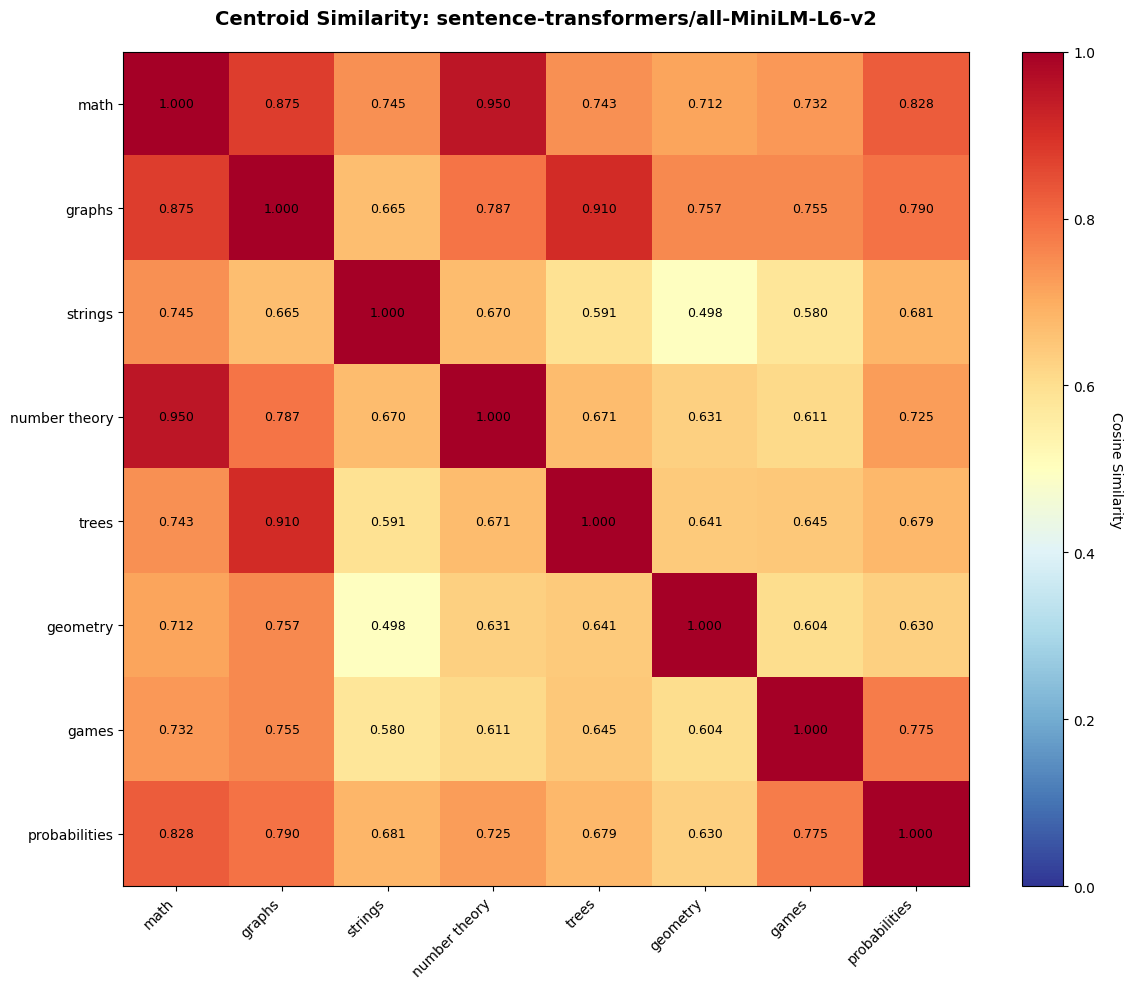


Heatmap sauvegardée: ../docs/embeddings/all-MiniLM-L6-v2_desc_only_centroid_similarity.png

[6/7] Calcul des distributions de similarité...

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
        games     39    0.314941  0.669559  0.354617
      strings    157    0.212086  0.561638  0.349552
        trees    120    0.191833  0.559502  0.367669
number theory    130    0.162041  0.570048  0.408007
     geometry     61    0.139544  0.487611  0.348067
probabilities     34    0.105373  0.504456  0.399083
         math    523    0.094759  0.507434  0.412676
       graphs    201    0.059450  0.488796  0.429346

✅ Meilleure séparation: games (Δmean=0.3149)
❌ Pire séparation: graphs (Δmean=0.0595)
📊 Moyenne Δmean: 0.1600

[7/7] Sauvegarde des embeddings...
   Embeddings: ../data/processed/all-MiniLM-L6-v2_desc_only_embeddings_train.npy
   Figures: ../docs/embeddings/all-MiniLM-L6-v2_desc_only_*.png

✅ ÉVALUATION TERMINÉE

📊 Résumé mpnet:
   Mean Δmean: 0.1600
  

In [18]:
# Exemple rapide: Tester un seul embedder
# Décommentez pour tester mpnet (meilleur modèle général de Sentence-Transformers)

col_interet = 'prob_desc_description_translated'

results_MiniLM = evaluate_embedder(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    df=df_reduced,
    text_column=col_interet,
    target_columns=label_columns,
    priority_tags=PRIORITY_TAGS,
    output_prefix='all-MiniLM-L6-v2_desc_only',
    max_words=400,
    batch_size=32,  # Réduire si problème de mémoire
    verbose=True
)

print(f"\n📊 Résumé mpnet:")
print(f"   Mean Δmean: {results_MiniLM['mean_delta_mean']:.4f}")
print(f"   Centroid similarity mean: {results_MiniLM['centroid_sim_mean']:.4f}")
print(f"   Best tag: {results_MiniLM['stats'].iloc[0]['tag']} (Δmean={results_MiniLM['stats'].iloc[0]['delta_mean']:.4f})")



ÉVALUATION EMBEDDER: sentence-transformers/all-mpnet-base-v2

[1/7] Preprocessing du texte...
   Documents tronqués: 15 / 992 (1.5%)

[2/7] Chargement du modèle 'sentence-transformers/all-mpnet-base-v2'...
   Modèle chargé: 768 dimensions

[3/7] Encoding de 992 documents...


Batches: 100%|██████████| 31/31 [10:06<00:00, 19.55s/it]


   Shape: (992, 768)
   Memory: 2.91 MB

[4/7] Calcul des centroids...

[5/7] Calcul de la matrice de similarité...

Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.901    0.801          0.955  0.782     0.774  0.736   
graphs         0.901   1.000    0.743          0.813  0.918     0.795  0.740   
strings        0.801   0.743    1.000          0.721  0.667     0.614  0.629   
number theory  0.955   0.813    0.721          1.000  0.704     0.689  0.646   
trees          0.782   0.918    0.667          0.704  1.000     0.690  0.672   
geometry       0.774   0.795    0.614          0.689  0.690     1.000  0.629   
games          0.736   0.740    0.629          0.646  0.672     0.629  1.000   
probabilities  0.803   0.761    0.689          0.704  0.693     0.629  0.727   

               probabilities  
math                   0.803  
graphs                 0.761  
strings                

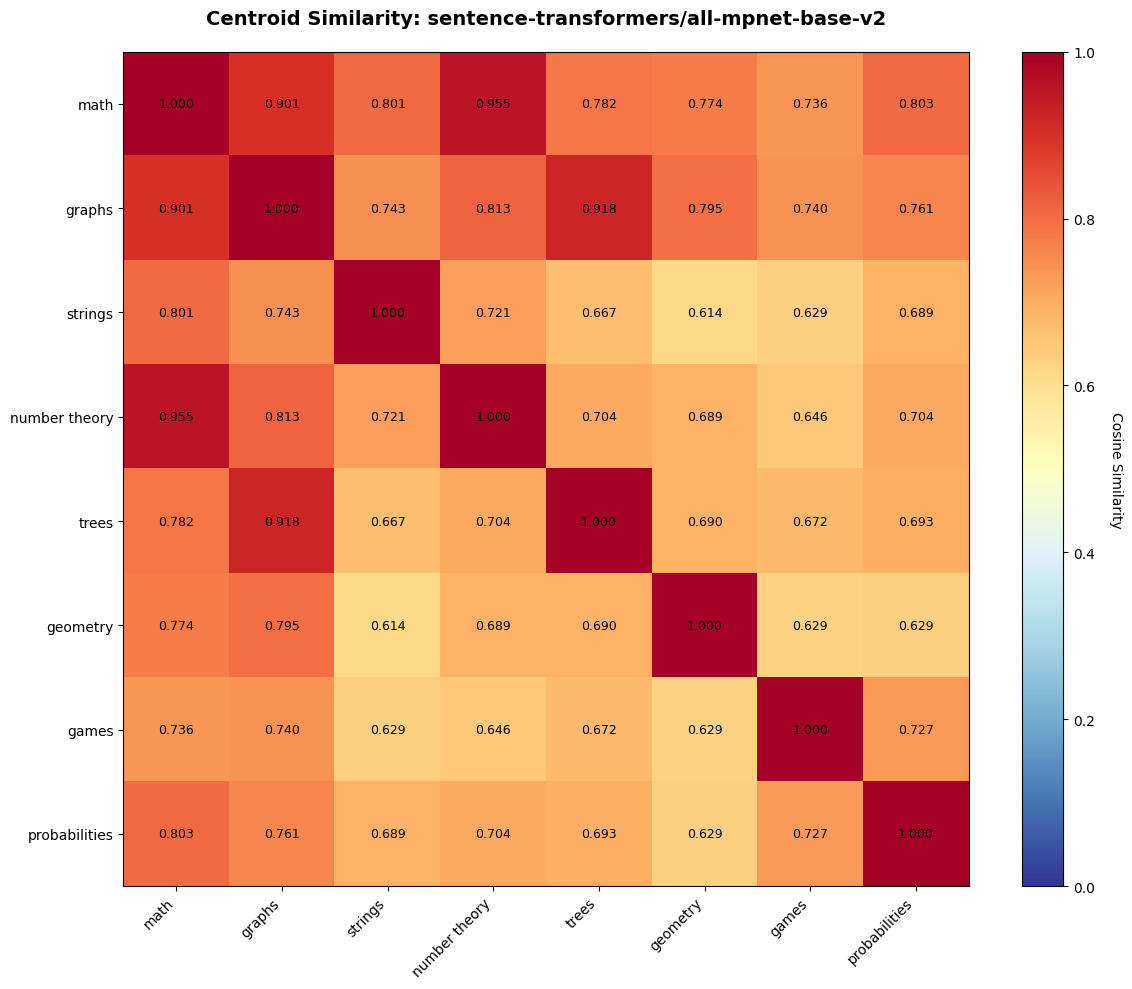


Heatmap sauvegardée: ../docs/embeddings/mpnet_desc_only_centroid_similarity.png

[6/7] Calcul des distributions de similarité...

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
        games     39    0.313701  0.709464  0.395763
      strings    157    0.190382  0.611045  0.420663
        trees    120    0.169137  0.598287  0.429150
number theory    130    0.139896  0.604259  0.464363
     geometry     61    0.132449  0.549524  0.417075
probabilities     34    0.131229  0.559063  0.427834
         math    523    0.076347  0.554424  0.478077
       graphs    201    0.062360  0.549374  0.487014

✅ Meilleure séparation: games (Δmean=0.3137)
❌ Pire séparation: graphs (Δmean=0.0624)
📊 Moyenne Δmean: 0.1519

[7/7] Sauvegarde des embeddings...
   Embeddings: ../data/processed/mpnet_desc_only_embeddings_train.npy
   Figures: ../docs/embeddings/mpnet_desc_only_*.png

✅ ÉVALUATION TERMINÉE

📊 Résumé mpnet:
   Mean Δmean: 0.1519
   Centroid similarity mean: 0.7366

In [19]:
# Exemple rapide: Tester un seul embedder
# Décommentez pour tester mpnet (meilleur modèle général de Sentence-Transformers)

col_interet = 'prob_desc_description_translated'

results_mpnet = evaluate_embedder(
    model_name='sentence-transformers/all-mpnet-base-v2',
    df=df_reduced,
    text_column=col_interet,
    target_columns=label_columns,
    priority_tags=PRIORITY_TAGS,
    output_prefix='mpnet_desc_only',
    max_words=400,
    batch_size=32,  # Réduire si problème de mémoire
    verbose=True
)

print(f"\n📊 Résumé mpnet:")
print(f"   Mean Δmean: {results_mpnet['mean_delta_mean']:.4f}")
print(f"   Centroid similarity mean: {results_mpnet['centroid_sim_mean']:.4f}")
print(f"   Best tag: {results_mpnet['stats'].iloc[0]['tag']} (Δmean={results_mpnet['stats'].iloc[0]['delta_mean']:.4f})")



ÉVALUATION EMBEDDER: sentence-transformers/allenai-specter

[1/7] Preprocessing du texte...
   Documents tronqués: 15 / 992 (1.5%)

[2/7] Chargement du modèle 'sentence-transformers/allenai-specter'...
   Modèle chargé: 768 dimensions

[3/7] Encoding de 992 documents...


Batches: 100%|██████████| 31/31 [06:55<00:00, 13.39s/it]


   Shape: (992, 768)
   Memory: 2.91 MB

[4/7] Calcul des centroids...

[5/7] Calcul de la matrice de similarité...

Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.983    0.979          0.995  0.968     0.967  0.953   
graphs         0.983   1.000    0.961          0.968  0.992     0.978  0.957   
strings        0.979   0.961    1.000          0.970  0.952     0.942  0.930   
number theory  0.995   0.968    0.970          1.000  0.955     0.946  0.935   
trees          0.968   0.992    0.952          0.955  1.000     0.968  0.948   
geometry       0.967   0.978    0.942          0.946  0.968     1.000  0.941   
games          0.953   0.957    0.930          0.935  0.948     0.941  1.000   
probabilities  0.984   0.977    0.965          0.971  0.966     0.962  0.974   

               probabilities  
math                   0.984  
graphs                 0.977  
strings                

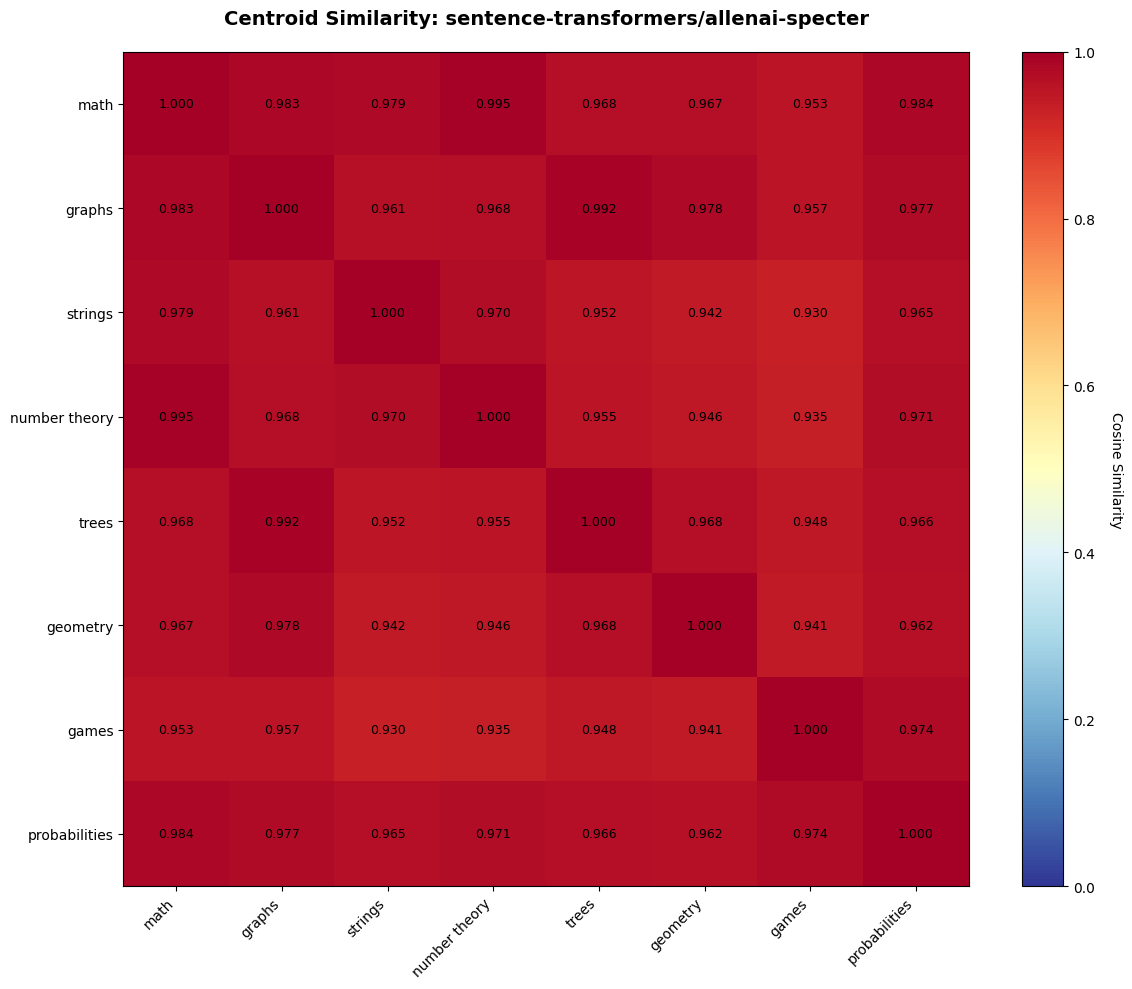


Heatmap sauvegardée: ../docs/embeddings/specter_desc_only_centroid_similarity.png

[6/7] Calcul des distributions de similarité...

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
        games     39    0.079521  0.900482  0.820961
      strings    157    0.047895  0.883135  0.835241
number theory    130    0.041867  0.884128  0.842261
        trees    120    0.040782  0.877249  0.836467
     geometry     61    0.026757  0.862174  0.835417
         math    523    0.014994  0.862938  0.847944
probabilities     34    0.011999  0.858352  0.846353
       graphs    201    0.007296  0.856205  0.848909

✅ Meilleure séparation: games (Δmean=0.0795)
❌ Pire séparation: graphs (Δmean=0.0073)
📊 Moyenne Δmean: 0.0339

[7/7] Sauvegarde des embeddings...
   Embeddings: ../data/processed/specter_desc_only_embeddings_train.npy
   Figures: ../docs/embeddings/specter_desc_only_*.png

✅ ÉVALUATION TERMINÉE

📊 Résumé mpnet:
   Mean Δmean: 0.0339
   Centroid similarity mean: 

In [20]:
col_interet = 'prob_desc_description_translated'

results_mpnet = evaluate_embedder(
    model_name='sentence-transformers/allenai-specter',
    df=df_reduced,
    text_column=col_interet,
    target_columns=label_columns,
    priority_tags=PRIORITY_TAGS,
    output_prefix='specter_desc_only',
    max_words=400,
    batch_size=32,  # Réduire si problème de mémoire
    verbose=True
)

print(f"\n📊 Résumé mpnet:")
print(f"   Mean Δmean: {results_mpnet['mean_delta_mean']:.4f}")
print(f"   Centroid similarity mean: {results_mpnet['centroid_sim_mean']:.4f}")
print(f"   Best tag: {results_mpnet['stats'].iloc[0]['tag']} (Δmean={results_mpnet['stats'].iloc[0]['delta_mean']:.4f})")



ÉVALUATION EMBEDDER: sentence-transformers/allenai-specter

[1/7] Preprocessing du texte...
   Documents tronqués: 17 / 992 (1.7%)

[2/7] Chargement du modèle 'sentence-transformers/allenai-specter'...
   Modèle chargé: 768 dimensions

[3/7] Encoding de 992 documents...


Batches: 100%|██████████| 31/31 [10:39<00:00, 20.64s/it]


   Shape: (992, 768)
   Memory: 2.91 MB

[4/7] Calcul des centroids...

[5/7] Calcul de la matrice de similarité...

Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.984    0.980          0.994  0.973     0.972  0.959   
graphs         0.984   1.000    0.964          0.970  0.992     0.980  0.962   
strings        0.980   0.964    1.000          0.971  0.955     0.947  0.937   
number theory  0.994   0.970    0.971          1.000  0.961     0.953  0.942   
trees          0.973   0.992    0.955          0.961  1.000     0.967  0.952   
geometry       0.972   0.980    0.947          0.953  0.967     1.000  0.946   
games          0.959   0.962    0.937          0.942  0.952     0.946  1.000   
probabilities  0.988   0.980    0.969          0.977  0.970     0.964  0.976   

               probabilities  
math                   0.988  
graphs                 0.980  
strings                

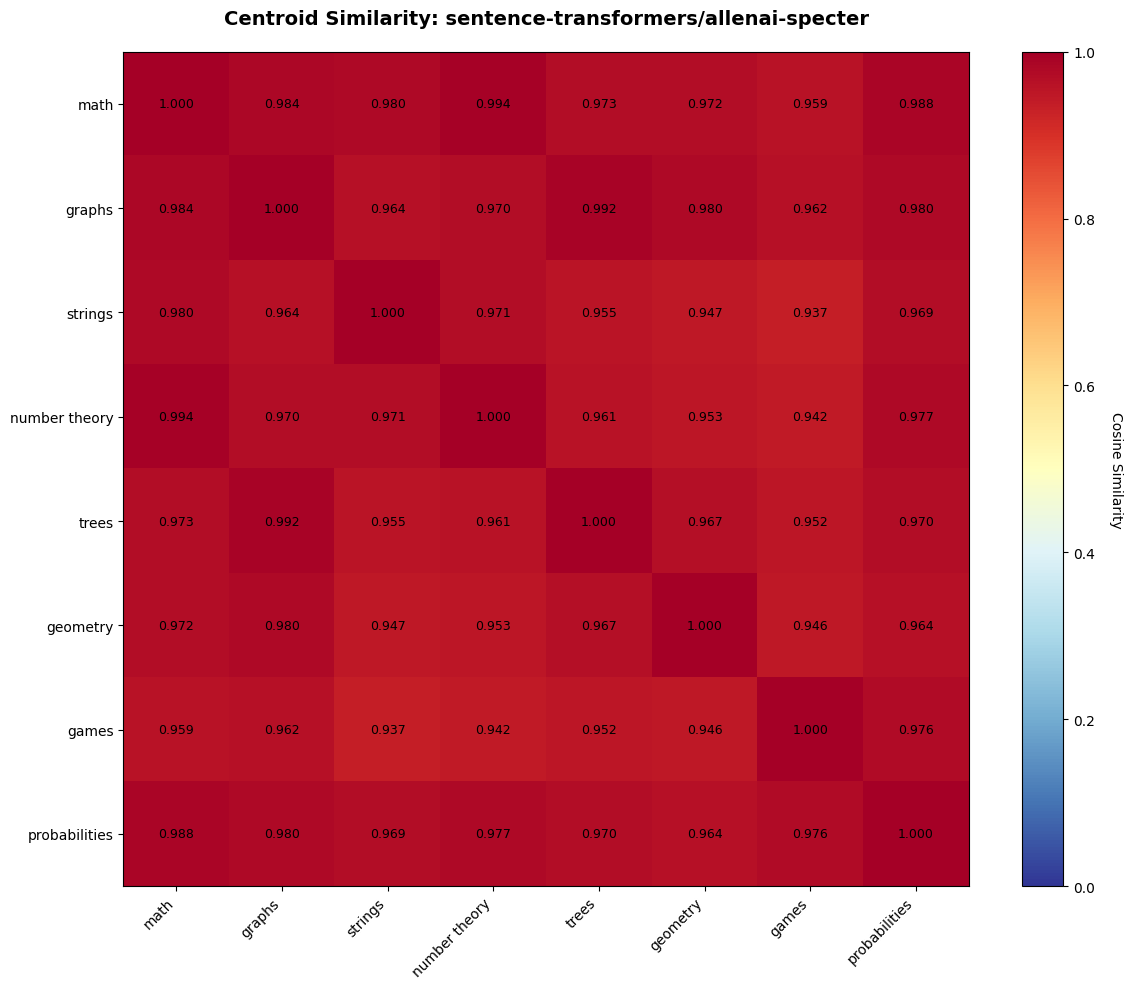


Heatmap sauvegardée: ../docs/embeddings/specter_desc_only_centroid_similarity.png

[6/7] Calcul des distributions de similarité...

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
        games     39    0.069122  0.903061  0.833939
      strings    157    0.043787  0.889226  0.845439
number theory    130    0.041699  0.893362  0.851663
        trees    120    0.037523  0.884738  0.847215
     geometry     61    0.021870  0.868631  0.846761
         math    523    0.015662  0.872548  0.856886
probabilities     34    0.012260  0.869799  0.857539
       graphs    201    0.006149  0.864712  0.858563

✅ Meilleure séparation: games (Δmean=0.0691)
❌ Pire séparation: graphs (Δmean=0.0061)
📊 Moyenne Δmean: 0.0310

[7/7] Sauvegarde des embeddings...
   Embeddings: ../data/processed/specter_desc_only_embeddings_train.npy
   Figures: ../docs/embeddings/specter_desc_only_*.png

✅ ÉVALUATION TERMINÉE

📊 Résumé mpnet:
   Mean Δmean: 0.0310
   Centroid similarity mean: 

In [23]:
# test sans clean latex
col_interet = 'prob_desc_description_translated'

results_mpnet = evaluate_embedder(
    model_name='sentence-transformers/allenai-specter',
    df=df_reduced,
    text_column=col_interet,
    target_columns=label_columns,
    priority_tags=PRIORITY_TAGS,
    output_prefix='specter_desc_only',
    max_words=400,
    batch_size=32,  # Réduire si problème de mémoire
    verbose=True,
    replace_latex = False
)

print(f"\n📊 Résumé mpnet:")
print(f"   Mean Δmean: {results_mpnet['mean_delta_mean']:.4f}")
print(f"   Centroid similarity mean: {results_mpnet['centroid_sim_mean']:.4f}")
print(f"   Best tag: {results_mpnet['stats'].iloc[0]['tag']} (Δmean={results_mpnet['stats'].iloc[0]['delta_mean']:.4f})")


## 2.2 : Analyse sur les labels peu performants

Objectif voir si il y a plus de signal discrimimant dans une autre colonne


ANALYSE COMPARATIVE DES COLONNES TEXTUELLES

Objectif: Identifier quelle(s) colonne(s) contiennent le plus d'information discriminante
Modèle: all-MiniLM-L6-v2 (384 dimensions)

TESTING COLUMN: prob_desc_description_translated

Coverage: 100.0% (3,978/3,978)
Avg length: 952 chars


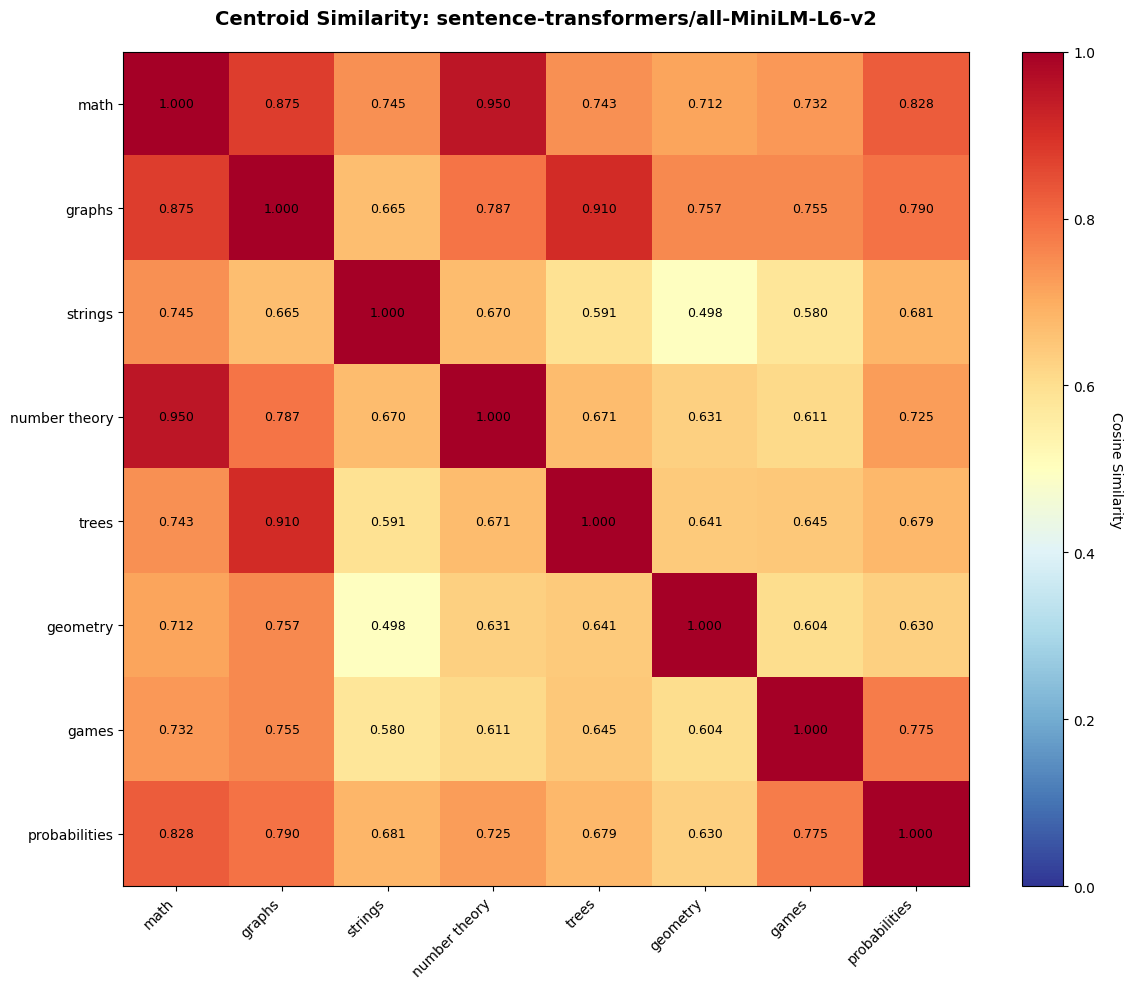


TESTING COLUMN: prob_desc_input_spec_translated

Coverage: 99.4% (3,953/3,978)
Avg length: 407 chars

TESTING COLUMN: prob_desc_output_spec_translated

Coverage: 98.5% (3,917/3,978)
Avg length: 208 chars


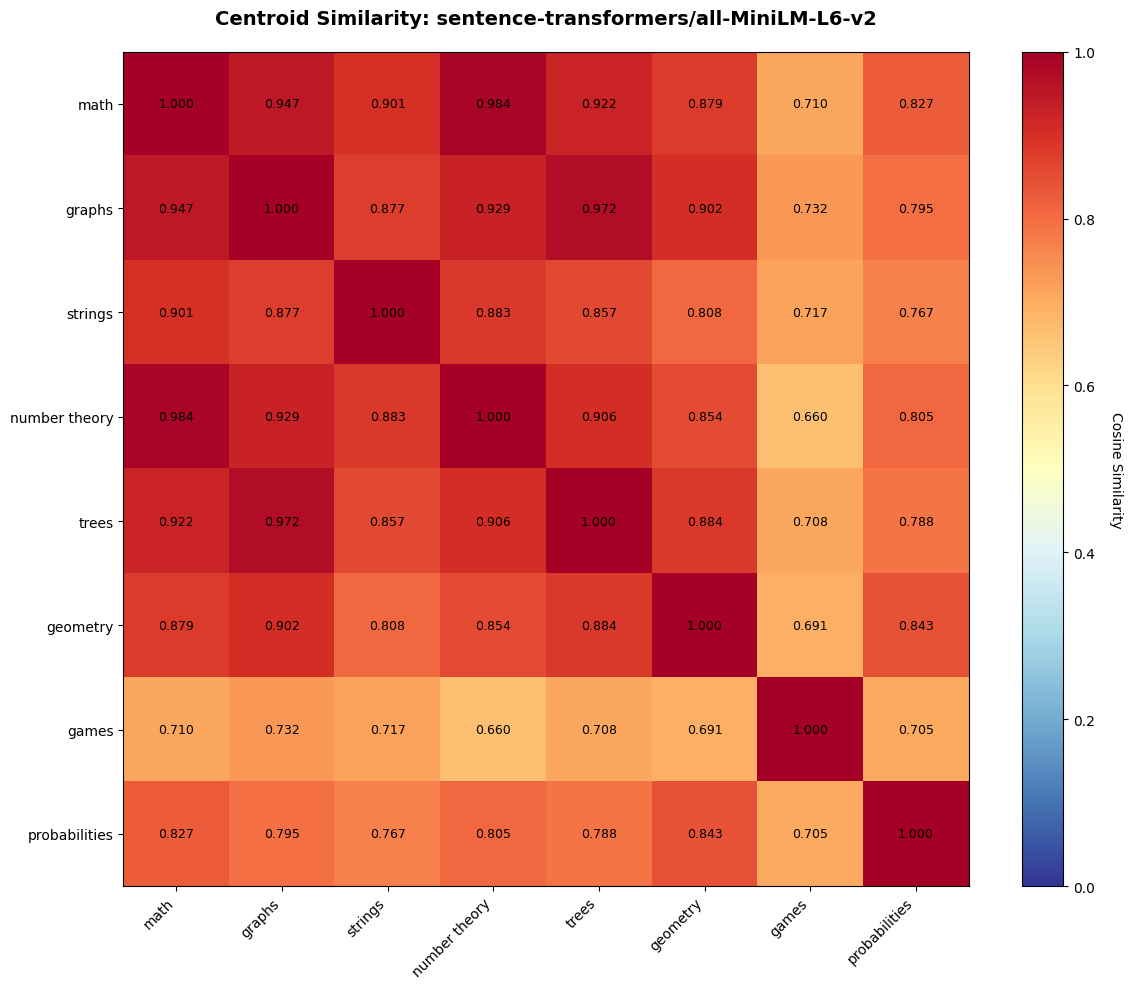


TESTING COLUMN: prob_desc_notes_translated

Coverage: 73.0% (2,905/3,978)
Avg length: 439 chars


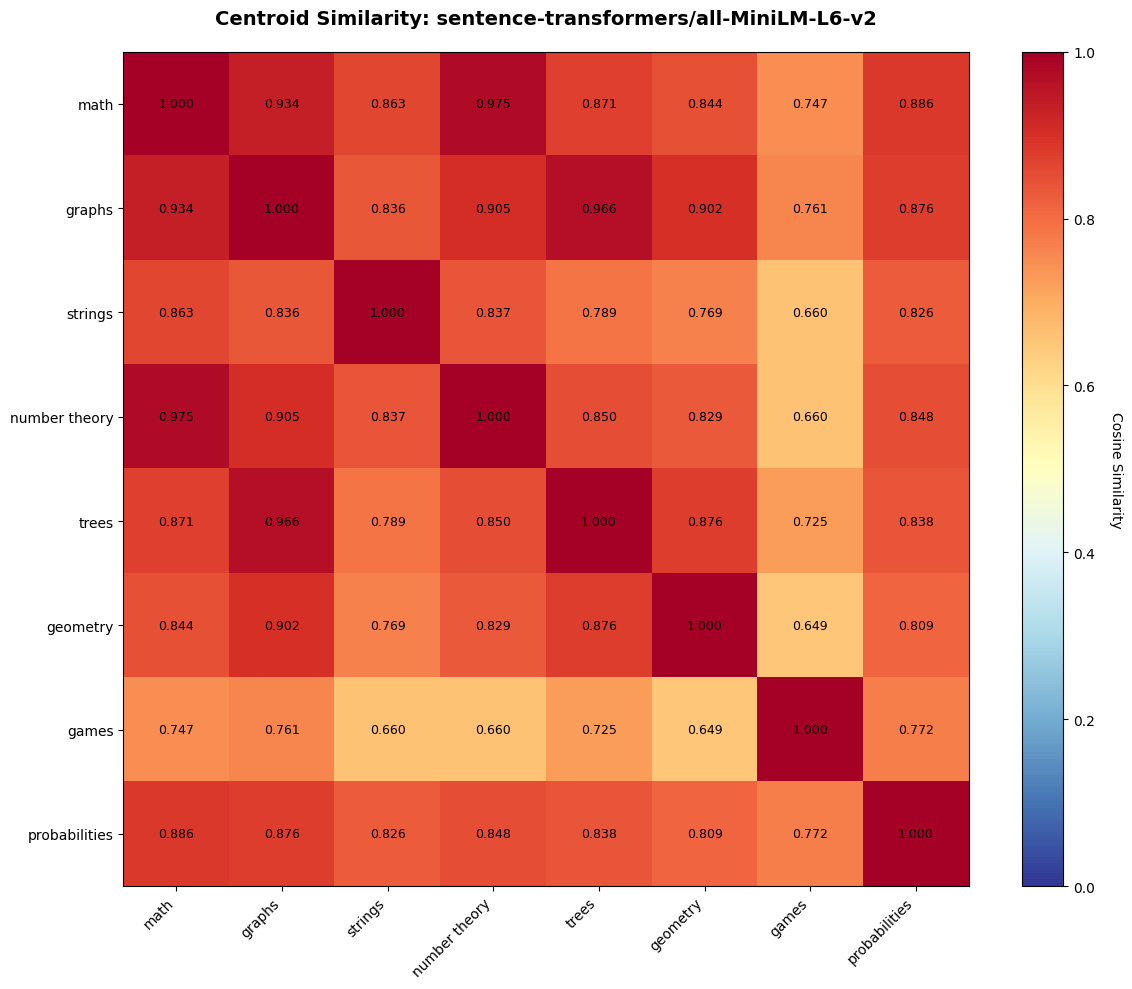

In [21]:
## 2.2 Analyse par Colonne Textuelle

print("\n" + "="*100)
print("ANALYSE COMPARATIVE DES COLONNES TEXTUELLES")
print("="*100)
print("\nObjectif: Identifier quelle(s) colonne(s) contiennent le plus d'information discriminante")
print("Modèle: all-MiniLM-L6-v2 (384 dimensions)")

# Colonnes à tester
text_columns_to_test = [
    'prob_desc_description_translated',
    'prob_desc_input_spec_translated',
    'prob_desc_output_spec_translated',
    'prob_desc_notes_translated'
]

# Dictionnaire pour stocker les résultats
results_by_column = {}

# Boucle d'évaluation
for col in text_columns_to_test:
    print(f"\n{'='*100}")
    print(f"TESTING COLUMN: {col}")
    print(f"{'='*100}")
    
    # Analyser la sparsité
    non_empty = df[col].notna() & (df[col].str.strip() != '')
    coverage = non_empty.sum() / len(df) * 100
    avg_length = df.loc[non_empty, col].str.len().mean()
    
    print(f"\nCoverage: {coverage:.1f}% ({non_empty.sum():,}/{len(df):,})")
    print(f"Avg length: {avg_length:.0f} chars")
    
    # Évaluer l'embedder
    results = evaluate_embedder(
        model_name='sentence-transformers/all-MiniLM-L6-v2',
        df=df_reduced,
        text_column=col,
        target_columns=label_columns,
        priority_tags=PRIORITY_TAGS,
        output_prefix=f'minilm_{col.split("_")[2]}',  # description, input, output, notes
        max_words=400,
        batch_size=32,
        verbose=False
    )
    
    results['column'] = col
    results['coverage'] = coverage
    results['avg_length'] = avg_length
    results_by_column[col] = results



COMPARATIVE ANALYSIS (triés par Mean Δmean décroissant)
     Column  Mean Δmean  Weighted Δmean  Centroid Sim  Coverage %  Avg Length Best Tag  Best Δmean
description    0.160004        0.129066      0.710128  100.000000         951    games    0.314941
output_spec    0.087274        0.068839      0.830521   98.466566         208    games    0.230992
      notes    0.077959        0.062362      0.825124   73.026647         439    games    0.206108
 input_spec    0.063868        0.082593      0.897626   99.371543         407  strings    0.122551

📊 Légende:
  - Mean Δmean:     Moyenne simple des Δmean des 8 tags
  - Weighted Δmean: Moyenne pondérée par le nombre de positifs de chaque tag
  - Centroid Sim:   Similarité moyenne entre centroids (↓ meilleur)
  - Coverage:       % de documents non-vides

HEATMAP: Δmean par Tag et Colonne

Δmean par (Tag × Colonne):
               description  output_spec     notes  input_spec
tag                                                          
gam

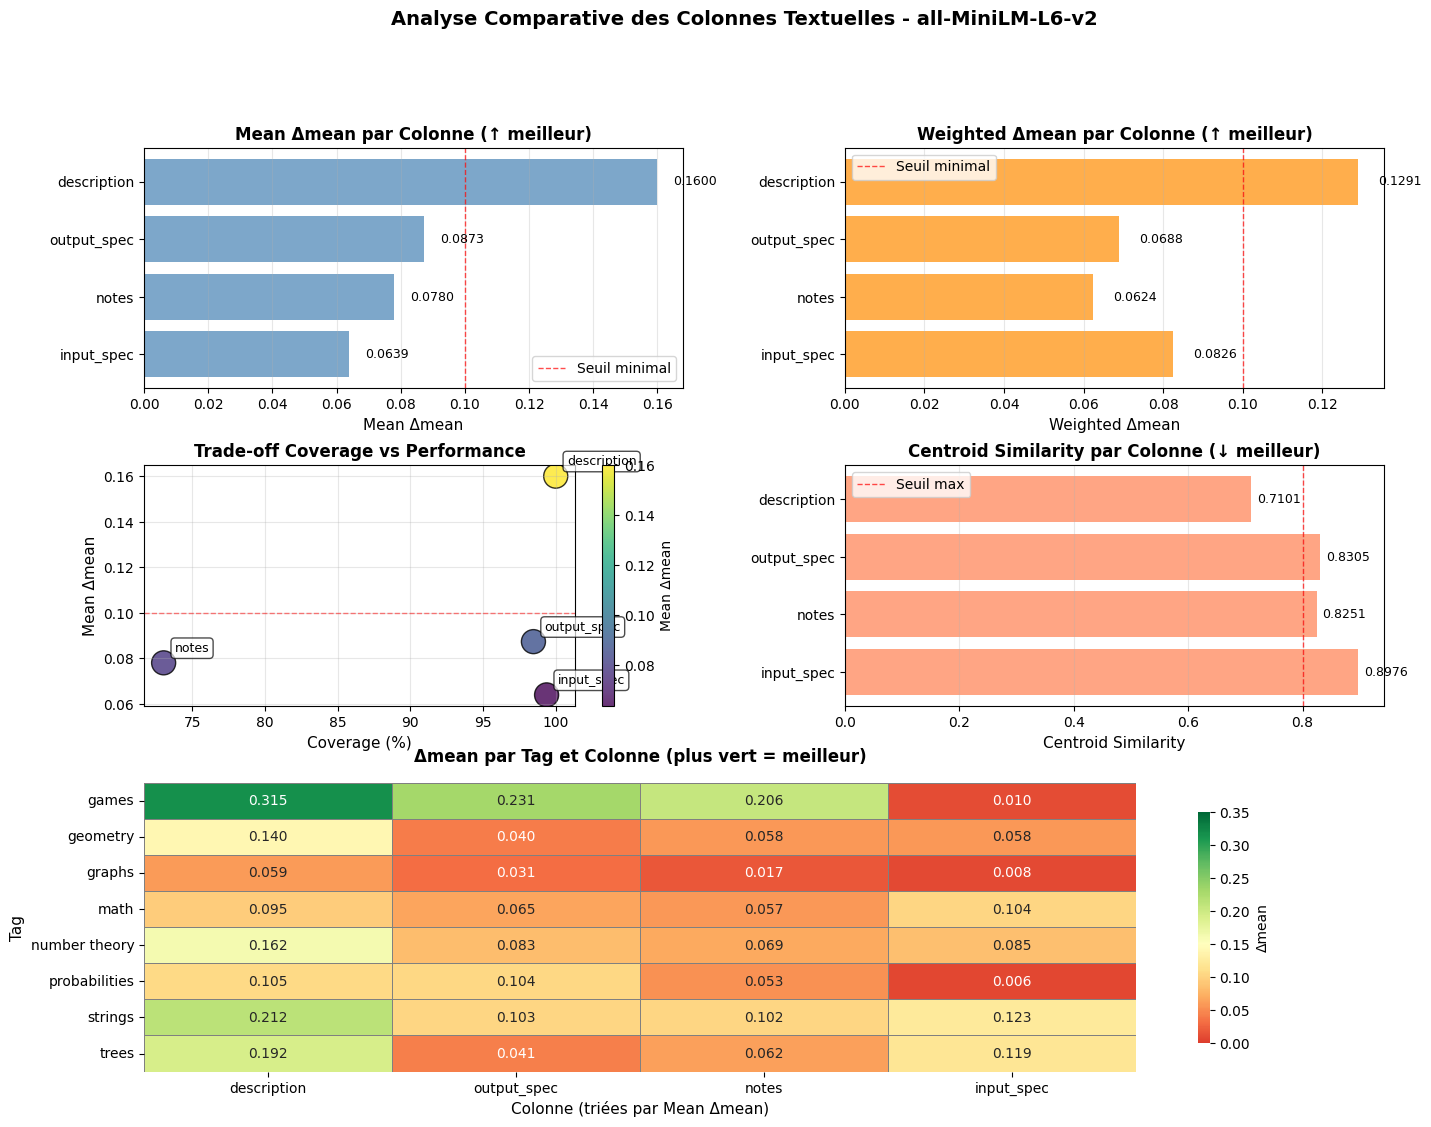


✅ Analyse terminée
📁 Graphiques sauvegardés: ../docs/embeddings/column_comparison_complete.png


In [22]:

# Construire le tableau comparatif
comparison_data = []
for col, res in results_by_column.items():
    # Calculer la moyenne pondérée des Δmean par le nombre de positifs
    stats_df = res['stats']
    weighted_delta_mean = (stats_df['delta_mean'] * stats_df['n_pos']).sum() / stats_df['n_pos'].sum()
    
    comparison_data.append({
        'Column': col.replace('prob_desc_', '').replace('_translated', ''),
        'Mean Δmean': res['mean_delta_mean'],
        'Weighted Δmean': weighted_delta_mean,
        'Centroid Sim': res['centroid_sim_mean'],
        'Coverage %': res['coverage'],
        'Avg Length': int(res['avg_length']),
        'Best Tag': res['stats'].iloc[0]['tag'],
        'Best Δmean': res['stats'].iloc[0]['delta_mean']
    })

# Créer DataFrame et trier par Mean Δmean décroissant
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Mean Δmean', ascending=False).reset_index(drop=True)

# Affichage du tableau
print("\n" + "="*100)
print("COMPARATIVE ANALYSIS (triés par Mean Δmean décroissant)")
print("="*100)
print(comparison_df.to_string(index=False))

print("\n📊 Légende:")
print("  - Mean Δmean:     Moyenne simple des Δmean des 8 tags")
print("  - Weighted Δmean: Moyenne pondérée par le nombre de positifs de chaque tag")
print("  - Centroid Sim:   Similarité moyenne entre centroids (↓ meilleur)")
print("  - Coverage:       % de documents non-vides")

# Créer la heatmap des Δmean individuels par (tag × colonne)
print("\n" + "="*100)
print("HEATMAP: Δmean par Tag et Colonne")
print("="*100)

# Construire la matrice (tags en lignes, colonnes en colonnes)
tag_performance_data = {}
for col, res in results_by_column.items():
    col_name = col.replace('prob_desc_', '').replace('_translated', '')
    tag_performance_data[col_name] = res['stats'].set_index('tag')['delta_mean']

tag_performance_df = pd.DataFrame(tag_performance_data)

# Trier les colonnes par Mean Δmean décroissant (même ordre que le tableau)
column_order = comparison_df['Column'].tolist()
tag_performance_df = tag_performance_df[column_order]

# Afficher les valeurs
print("\nΔmean par (Tag × Colonne):")
print(tag_performance_df.to_string())

# Graphiques comparatifs
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.3, wspace=0.3)

# 1. Mean Δmean par colonne (trié)
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.barh(comparison_df['Column'], comparison_df['Mean Δmean'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Mean Δmean', fontsize=11)
ax1.set_title('Mean Δmean par Colonne (↑ meilleur)', fontsize=12, fontweight='bold')
ax1.axvline(x=0.10, color='red', linestyle='--', linewidth=1, label='Seuil minimal', alpha=0.7)
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Annoter les valeurs
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    ax1.text(row['Mean Δmean'] + 0.005, i, f"{row['Mean Δmean']:.4f}", 
             va='center', fontsize=9)

# 2. Weighted Δmean par colonne (trié)
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.barh(comparison_df['Column'], comparison_df['Weighted Δmean'], color='darkorange', alpha=0.7)
ax2.set_xlabel('Weighted Δmean', fontsize=11)
ax2.set_title('Weighted Δmean par Colonne (↑ meilleur)', fontsize=12, fontweight='bold')
ax2.axvline(x=0.10, color='red', linestyle='--', linewidth=1, label='Seuil minimal', alpha=0.7)
ax2.legend()
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# Annoter les valeurs
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    ax2.text(row['Weighted Δmean'] + 0.005, i, f"{row['Weighted Δmean']:.4f}", 
             va='center', fontsize=9)

# 3. Coverage vs Performance
ax3 = fig.add_subplot(gs[1, 0])
scatter = ax3.scatter(
    comparison_df['Coverage %'], 
    comparison_df['Mean Δmean'],
    s=300,
    c=comparison_df['Mean Δmean'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='black',
    linewidths=1
)
for idx, row in comparison_df.iterrows():
    ax3.annotate(
        row['Column'], 
        (row['Coverage %'], row['Mean Δmean']),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )
ax3.set_xlabel('Coverage (%)', fontsize=11)
ax3.set_ylabel('Mean Δmean', fontsize=11)
ax3.set_title('Trade-off Coverage vs Performance', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.axhline(y=0.10, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.colorbar(scatter, ax=ax3, label='Mean Δmean')

# 4. Centroid Similarity comparison
ax4 = fig.add_subplot(gs[1, 1])
ax4.barh(comparison_df['Column'], comparison_df['Centroid Sim'], color='coral', alpha=0.7)
ax4.set_xlabel('Centroid Similarity', fontsize=11)
ax4.set_title('Centroid Similarity par Colonne (↓ meilleur)', fontsize=12, fontweight='bold')
ax4.axvline(x=0.80, color='red', linestyle='--', linewidth=1, label='Seuil max', alpha=0.7)
ax4.legend()
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()

# Annoter les valeurs
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    ax4.text(row['Centroid Sim'] + 0.01, i, f"{row['Centroid Sim']:.4f}", 
             va='center', fontsize=9)

# 5. Heatmap Δmean par (Tag × Colonne) - PLUS GRANDE
ax5 = fig.add_subplot(gs[2, :])
sns.heatmap(
    tag_performance_df,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0.15,
    vmin=0,
    vmax=0.35,
    cbar_kws={'label': 'Δmean', 'shrink': 0.8},
    linewidths=0.5,
    linecolor='gray',
    ax=ax5
)
ax5.set_title('Δmean par Tag et Colonne (plus vert = meilleur)', fontsize=12, fontweight='bold', pad=15)
ax5.set_xlabel('Colonne (triées par Mean Δmean)', fontsize=11)
ax5.set_ylabel('Tag', fontsize=11)

plt.suptitle('Analyse Comparative des Colonnes Textuelles - all-MiniLM-L6-v2', 
             fontsize=14, fontweight='bold', y=0.995)

plt.savefig('../docs/embeddings/column_comparison_complete.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Analyse terminée")
print(f"📁 Graphiques sauvegardés: ../docs/embeddings/column_comparison_complete.png")